In [ ]:
# 🔧 Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings("ignore")

# 📡 Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Using device: {device}")


📡 Using device: cuda


In [ ]:
# 📁 Load raw prices
file_path = "C:/Users/Shashwat/OneDrive/Desktop/ALL new resumes/CONSITUTIONAL LAW/SALARAY SLIP/GWP1_ML_IN_FINANCE/combined_data_2020_2024.csv"
raw_df = pd.read_csv(file_path, index_col=0, parse_dates=True).dropna()

# ✅ Convert to log returns
log_returns_df = np.log(raw_df / raw_df.shift(1)).dropna()


In [ ]:
# 🔁 Feature Engineering on log returns
def add_features(df, window=5):
    features = {}
    for col in df.columns:
        features[f"{col}_ret"] = df[col]
        features[f"{col}_vol"] = df[col].rolling(window).std()
        features[f"{col}_mean"] = df[col].rolling(window).mean()
        features[f"{col}_sharpe"] = features[f"{col}_mean"] / (features[f"{col}_vol"] + 1e-8)
    return pd.DataFrame(features).dropna()

features_df = add_features(log_returns_df).sort_index(axis=1)

# ✅ Add Random Forest prediction as a feature
use_rf_signal = True  # Set False to disable ensemble

if use_rf_signal:
    print("🧠 Training Random Forest for signal generation...")

    # Align both features and returns
    aligned_index = features_df.index.intersection(log_returns_df.index)
    features_df = features_df.loc[aligned_index]
    log_returns_df = log_returns_df.loc[aligned_index]

    # Drop last row to align features X and label y
    X_rf = features_df.iloc[:-1]
    y_rf = (log_returns_df.iloc[1:, 0] > 0).astype(int)

    # Train RF
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestClassifier

    scaler_rf = StandardScaler()
    X_rf_scaled = scaler_rf.fit_transform(X_rf)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_rf_scaled, y_rf)

    # Predict only on X_rf rows to maintain length
    rf_preds = rf.predict(X_rf_scaled)

    # Align and pad with NaN at the top to maintain full DataFrame length
    rf_signal_series = pd.Series([np.nan] + rf_preds.tolist(), index=features_df.index)

    # Drop initial row with NaN in rf_signal (aligns with target returns)
    features_df["rf_signal"] = rf_signal_series
    features_df = features_df.dropna()

else:
    print("⚠️ RF Signal not used.")


🧠 Training Random Forest for signal generation...


In [ ]:
# 📅 Train-test split
train_df = features_df[features_df.index < "2024-01-01"]
test_df = features_df[features_df.index >= "2024-01-01"]
train_returns = log_returns_df.loc[train_df.index]
test_returns = log_returns_df.loc[test_df.index]

print("✅ Features created and split.")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")


✅ Features created and split.
Train shape: (1000, 117), Test shape: (251, 117)


In [ ]:
# 🧱 Environment Class
class FeaturePortfolioEnv:
    def __init__(self, features_df, returns_df, seq_len=10):
        self.features = torch.tensor(features_df.values, dtype=torch.float32).to(device)
        self.returns = torch.tensor(returns_df.values, dtype=torch.float32).to(device)
        self.seq_len = seq_len
        self.n_assets = returns_df.shape[1]
        self.n_features = self.features.shape[1]
        self.reset()

    def reset(self):
        self.ptr = self.seq_len
        return self.features[self.ptr - self.seq_len:self.ptr].unsqueeze(0)

    def step(self, allocation_weights):
        today_return = self.returns[self.ptr]
        reward = torch.dot(allocation_weights[0], today_return)
        self.ptr += 1
        done = self.ptr >= len(self.returns)
        next_state = self.features[self.ptr - self.seq_len:self.ptr].unsqueeze(0) if not done else None
        return next_state, reward, done

# 🤖 LSTM Policy
class LSTMSoftPolicy(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, input_dim // 4)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        logits = self.fc(hn.squeeze(0))
        return self.softmax(logits)


In [ ]:
# 🏋️ Training loop
def train_soft_policy(env, model, epochs=200, gamma=0.99, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    rewards_all = []

    for epoch in range(epochs):
        state = env.reset()
        log_probs, rewards = [], []
        done = False

        while not done:
            action_probs = model(state)
            m = torch.distributions.Categorical(probs=action_probs.squeeze(0))
            action = m.sample()
            log_prob = torch.log(action_probs[0, action])
            allocation = action_probs

            next_state, reward, done = env.step(allocation)
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        loss = -torch.stack(log_probs).dot(returns)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        rewards_all.append(torch.sum(torch.tensor(rewards)).item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1} 🎯 Reward: {rewards_all[-1]:.4f}")

    return rewards_all


🚀 Training soft-allocation LSTM model...
Epoch 50 🎯 Reward: 0.2512
Epoch 100 🎯 Reward: 0.2487
Epoch 150 🎯 Reward: 0.2562
Epoch 200 🎯 Reward: 0.2414
Epoch 250 🎯 Reward: 0.2039
Epoch 300 🎯 Reward: 0.2251
✅ LSTM output shape: torch.Size([1, 29])
✅ LSTM output (weights): [[0.030278   0.03114928 0.02005044 0.04805731 0.0240825  0.01958081
  0.03086686 0.02469675 0.05703928 0.01511409 0.05489854 0.06664623
  0.02142745 0.04318211 0.0384278  0.08935529 0.0331131  0.05707556
  0.02247902 0.01800008 0.03173915 0.03606524 0.02443527 0.02975982
  0.02648506 0.01770359 0.02185656 0.04417705 0.02225779]]


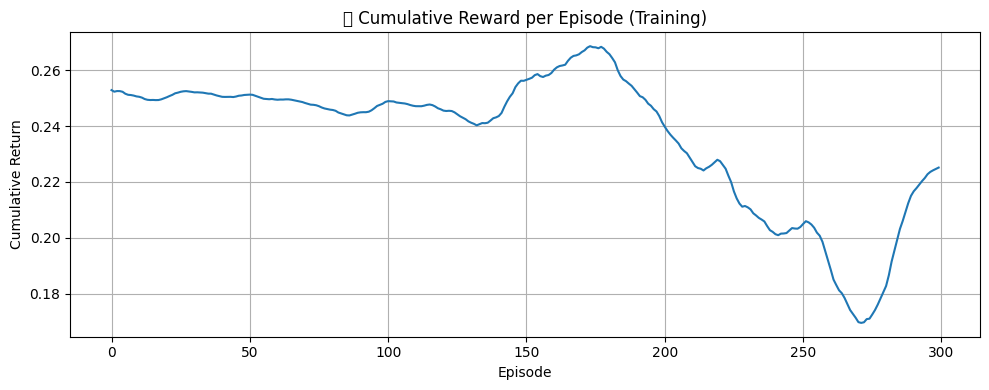

In [ ]:
# 🚀 Train model
seq_len = 10
train_env = FeaturePortfolioEnv(train_df, train_returns, seq_len)
input_dim = train_env.n_features
model = LSTMSoftPolicy(input_dim).to(device)

print("🚀 Training soft-allocation LSTM model...")
train_rewards = train_soft_policy(train_env, model, epochs=300)

# ✅ Model check
sample_input = train_env.reset()
out = model(sample_input)
print("✅ LSTM output shape:", out.shape)
print("✅ LSTM output (weights):", out.detach().cpu().numpy())

# 📈 Plot training rewards
plt.figure(figsize=(10, 4))
plt.plot(train_rewards)
plt.title("🎯 Cumulative Reward per Episode (Training)")
plt.xlabel("Episode")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()


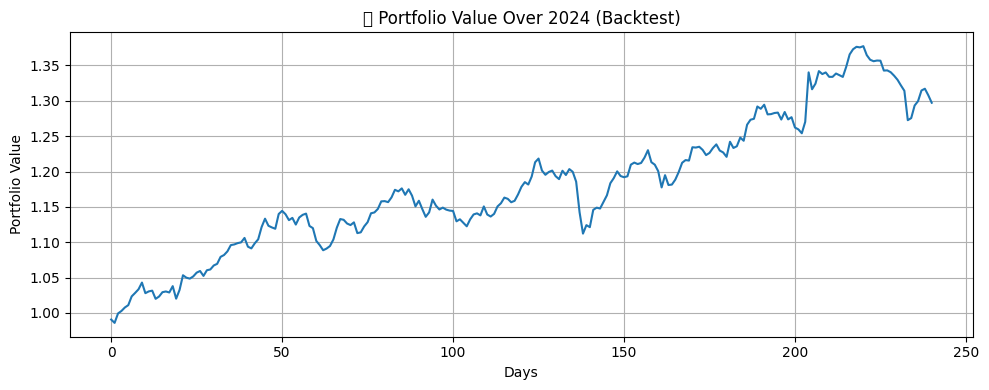

In [ ]:
# 📦 Backtesting
def backtest_policy(env, model, initial_cash=1.0):
    model.eval()
    state = env.reset()
    cash = initial_cash
    portfolio_values = []
    done = False

    with torch.no_grad():
        while not done:
            action_probs = model(state)
            allocation = action_probs
            next_state, reward, done = env.step(allocation)
            cash *= (1.0 + reward.item())
            portfolio_values.append(cash)
            state = next_state

    return portfolio_values

test_env = FeaturePortfolioEnv(test_df, test_returns, seq_len)
portfolio_values = backtest_policy(test_env, model)

plt.figure(figsize=(10, 4))
plt.plot(portfolio_values)
plt.title("💼 Portfolio Value Over 2024 (Backtest)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()


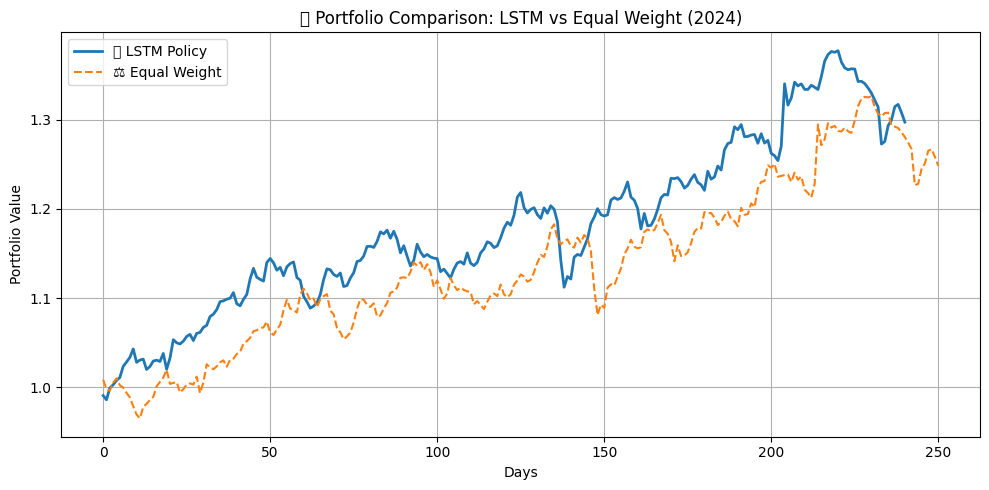

📊 Final Return (LSTM): 29.72%
📊 Final Return (Equal Weight): 24.84%


In [ ]:
# 📦 Equal Weight Backtest
def backtest_equal_weight(returns_df, initial_cash=1.0):
    weights = torch.tensor([1.0 / returns_df.shape[1]] * returns_df.shape[1], dtype=torch.float32).to(device)
    portfolio_values = [initial_cash]
    cash = initial_cash
    returns_tensor = torch.tensor(returns_df.values, dtype=torch.float32).to(device)

    for r in returns_tensor:
        cash *= (1.0 + torch.dot(weights, r).item())
        portfolio_values.append(cash)

    return portfolio_values[1:]

equal_weight_values = backtest_equal_weight(test_returns)

plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, label="📈 LSTM Policy", linewidth=2)
plt.plot(equal_weight_values, label="⚖️ Equal Weight", linestyle="--")
plt.title("📊 Portfolio Comparison: LSTM vs Equal Weight (2024)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Final Returns
lstm_return = portfolio_values[-1] - 1.0
equal_weight_return = equal_weight_values[-1] - 1.0
print(f"📊 Final Return (LSTM): {lstm_return:.2%}")
print(f"📊 Final Return (Equal Weight): {equal_weight_return:.2%}")


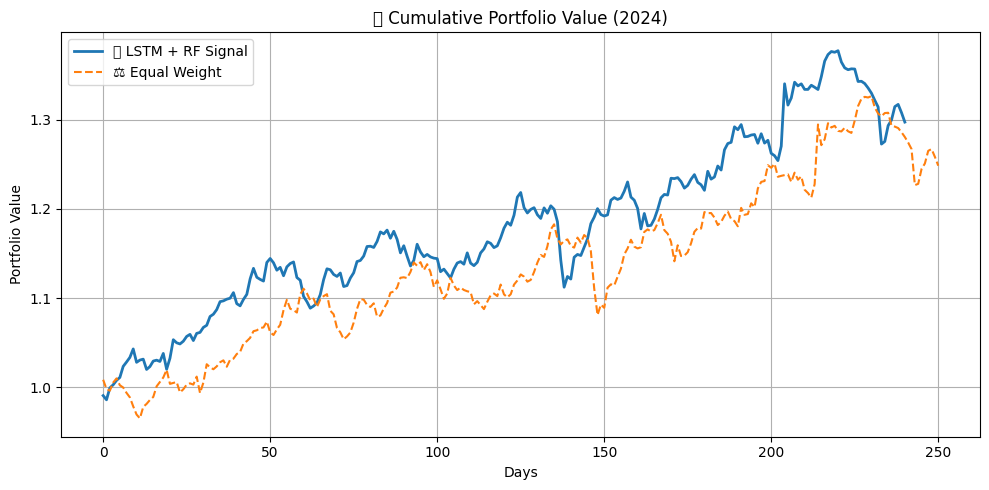

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(portfolio_values, label="📈 LSTM + RF Signal", linewidth=2)
plt.plot(equal_weight_values, label="⚖️ Equal Weight", linestyle="--")
plt.title("📊 Cumulative Portfolio Value (2024)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


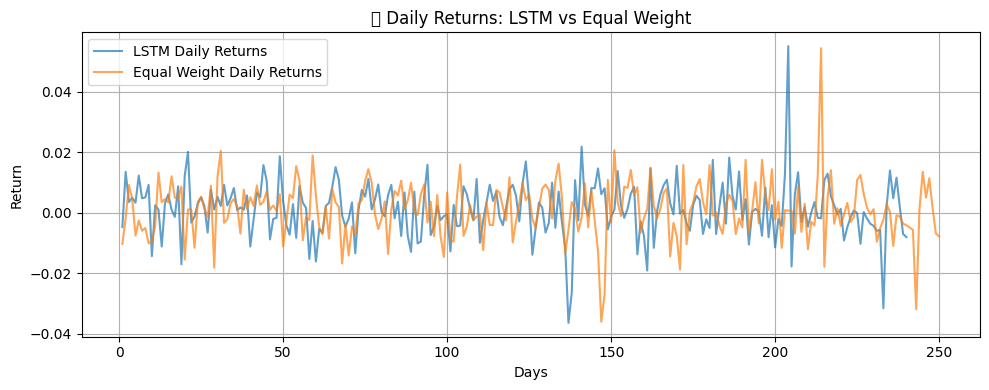

In [ ]:
lstm_returns = pd.Series(portfolio_values).pct_change().dropna()
equal_returns = pd.Series(equal_weight_values).pct_change().dropna()

plt.figure(figsize=(10, 4))
plt.plot(lstm_returns, label="LSTM Daily Returns", alpha=0.7)
plt.plot(equal_returns, label="Equal Weight Daily Returns", alpha=0.7)
plt.title("📊 Daily Returns: LSTM vs Equal Weight")
plt.xlabel("Days")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


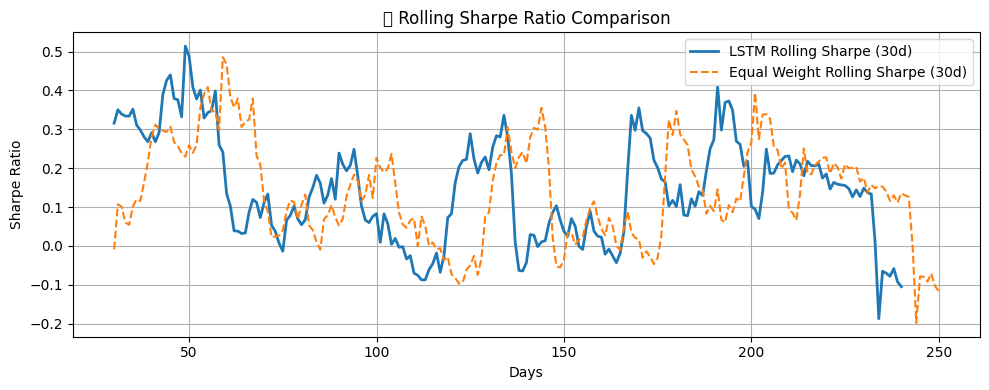

In [ ]:
def rolling_sharpe(returns, window=30):
    return returns.rolling(window).mean() / (returns.rolling(window).std() + 1e-8)

lstm_sharpe = rolling_sharpe(lstm_returns)
equal_sharpe = rolling_sharpe(equal_returns)

plt.figure(figsize=(10, 4))
plt.plot(lstm_sharpe, label="LSTM Rolling Sharpe (30d)", linewidth=2)
plt.plot(equal_sharpe, label="Equal Weight Rolling Sharpe (30d)", linestyle='--')
plt.title("📈 Rolling Sharpe Ratio Comparison")
plt.xlabel("Days")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


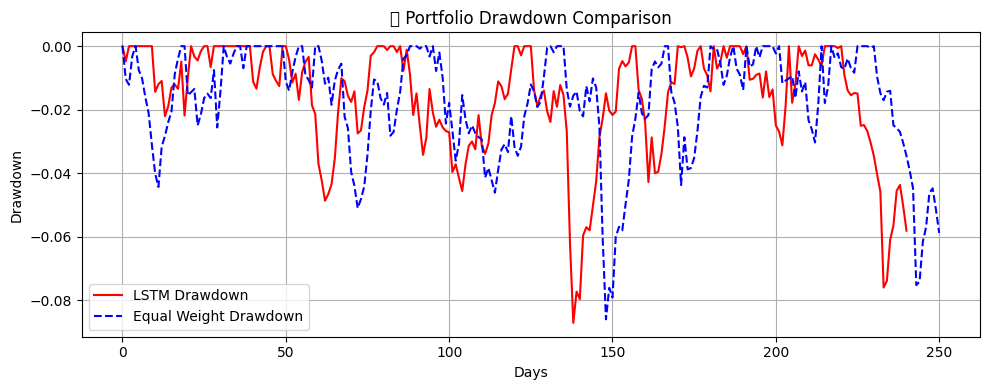

In [ ]:
def compute_drawdown(series):
    cum_max = series.cummax()
    return (series - cum_max) / cum_max

lstm_dd = compute_drawdown(pd.Series(portfolio_values))
equal_dd = compute_drawdown(pd.Series(equal_weight_values))

plt.figure(figsize=(10, 4))
plt.plot(lstm_dd, label="LSTM Drawdown", color='red')
plt.plot(equal_dd, label="Equal Weight Drawdown", color='blue', linestyle='--')
plt.title("📉 Portfolio Drawdown Comparison")
plt.xlabel("Days")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
